# Revenue Analytics & Reporting Module
### Business Dashboard — Data Analyst Intern Submission
**Reporting Period:** June 2024 – May 2025  
**Tools Used:** Python, Pandas, Matplotlib, NumPy  
**Prepared by:** Data Analyst Intern


## 1. Imports and Data Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 120
})

# ── Monthly revenue data ──
months      = ['Jun-24','Jul-24','Aug-24','Sep-24','Oct-24','Nov-24',
               'Dec-24','Jan-25','Feb-25','Mar-25','Apr-25','May-25']
full_months = ['June 2024','July 2024','August 2024','September 2024',
               'October 2024','November 2024','December 2024','January 2025',
               'February 2025','March 2025','April 2025','May 2025']

actual    = [182000,195000,178000,210000,245000,268000,290000,255000,220000,275000,310000,338000]
projected = [175000,190000,200000,215000,230000,255000,280000,270000,240000,260000,300000,320000]

df = pd.DataFrame({
    'Month'    : months,
    'Full_Month': full_months,
    'Actual'   : actual,
    'Projected': projected
})

df['Variance']   = df['Actual'] - df['Projected']
df['Variance_Pct'] = ((df['Actual'] - df['Projected']) / df['Projected'] * 100).round(1)
df['MoM_Growth'] = df['Actual'].pct_change() * 100
df['MoM_Growth'] = df['MoM_Growth'].round(1)

print("✅ Data loaded successfully")
print(f"   Months        : {len(df)}")
print(f"   Total Actual  : ${df['Actual'].sum():,.0f}")
print(f"   Total Projected: ${df['Projected'].sum():,.0f}")
df.head(3)


✅ Data loaded successfully
   Months        : 12
   Total Actual  : $2,966,000
   Total Projected: $2,935,000


,Month,Full_Month,Actual,Projected,Variance,Variance_Pct,MoM_Growth
0,Jun-24,June 2024,182000,175000,7000,4.0,NaN
1,Jul-24,July 2024,195000,190000,5000,2.6,7.1
2,Aug-24,August 2024,178000,200000,-22000,-11.0,-8.7


## 2. Month-wise Revenue — Last 12 Months

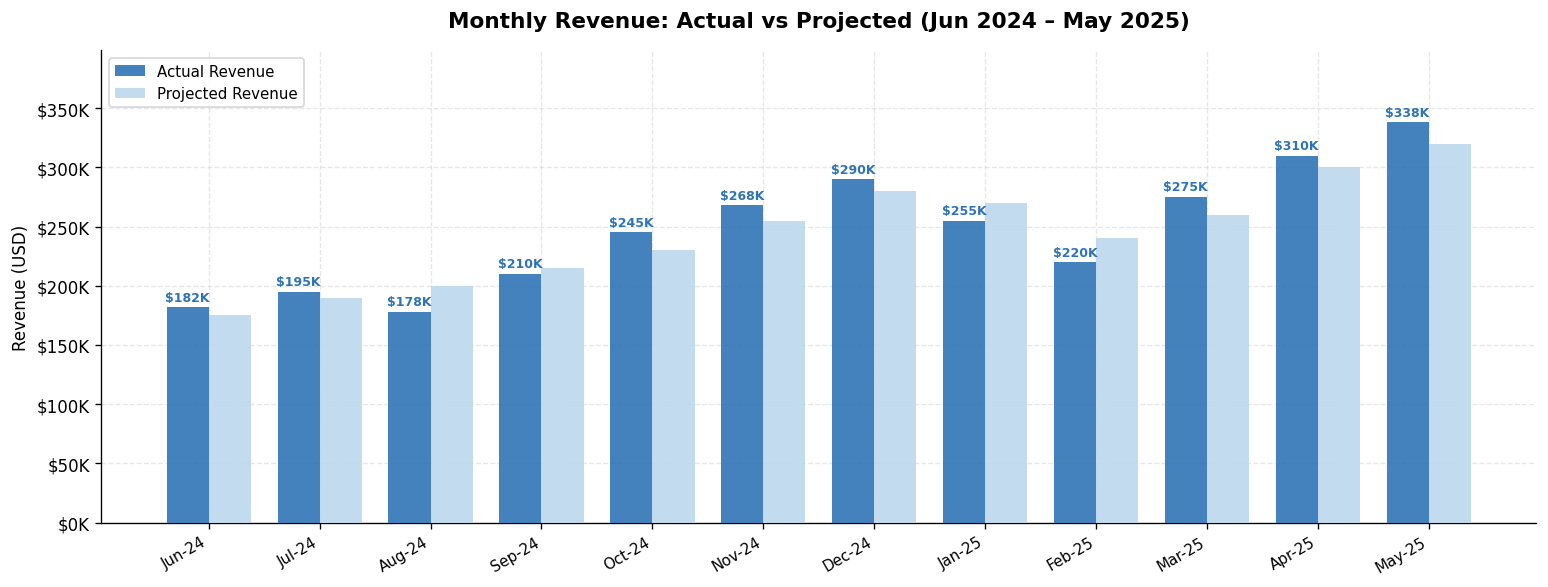

Peak month  : May 2025  →  $338,000
Lowest month: August 2024  →  $178,000


In [2]:
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(months))
w = 0.38

bars1 = ax.bar(x - w/2, df['Actual'],    width=w, label='Actual Revenue',    color='#2E74B5', alpha=0.9, zorder=3)
bars2 = ax.bar(x + w/2, df['Projected'], width=w, label='Projected Revenue', color='#BDD7EE', alpha=0.9, zorder=3)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
            f'${bar.get_height()/1000:.0f}K', ha='center', va='bottom', fontsize=7.5, color='#2E74B5', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(months, rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))
ax.set_title('Monthly Revenue: Actual vs Projected (Jun 2024 – May 2025)', fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('Revenue (USD)', fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, max(actual) * 1.18)

plt.tight_layout()
plt.savefig('monthly_revenue.png', bbox_inches='tight')
plt.show()
print(f"Peak month  : {df.loc[df['Actual'].idxmax(), 'Full_Month']}  →  ${df['Actual'].max():,.0f}")
print(f"Lowest month: {df.loc[df['Actual'].idxmin(), 'Full_Month']}  →  ${df['Actual'].min():,.0f}")


## 3. MoM and QoQ Growth Analysis

Month-over-Month Growth
         Month Actual Revenue MoM Growth %
     June 2024       $182,000            —
     July 2024       $195,000        +7.1%
   August 2024       $178,000        -8.7%
September 2024       $210,000       +18.0%
  October 2024       $245,000       +16.7%
 November 2024       $268,000        +9.4%
 December 2024       $290,000        +8.2%
  January 2025       $255,000       -12.1%
 February 2025       $220,000       -13.7%
    March 2025       $275,000       +25.0%
    April 2025       $310,000       +12.7%
      May 2025       $338,000        +9.0%


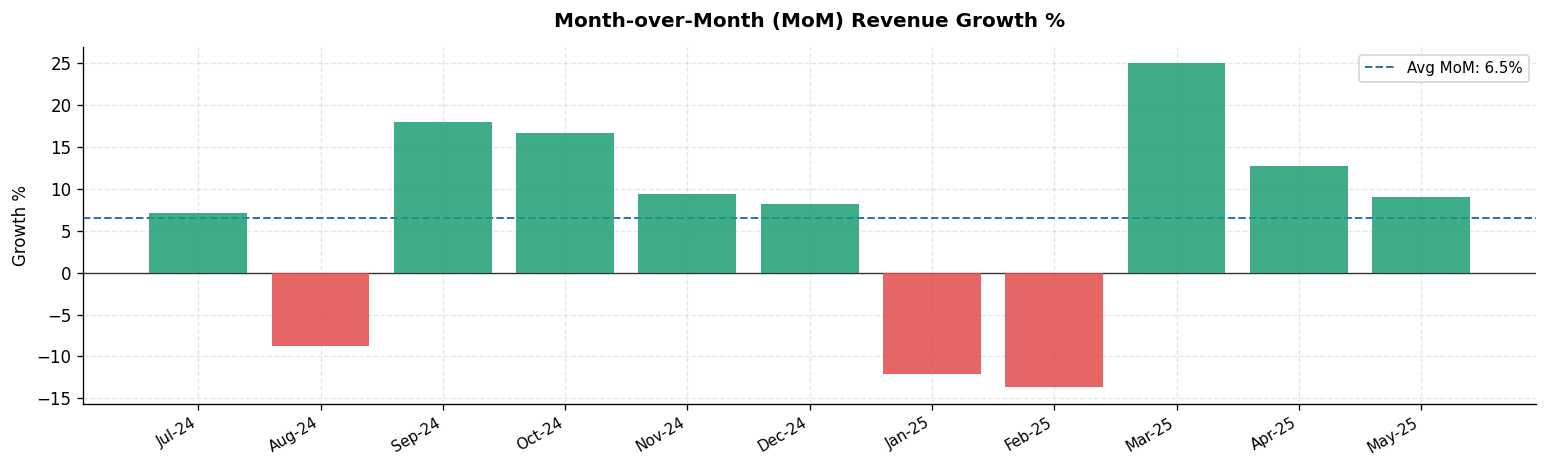


Average MoM Growth : 6.5%
Best MoM  : Mar-25  (25.0%)
Worst MoM : Feb-25  (-13.7%)


In [3]:
# ── MoM table ──
mom_df = df[['Full_Month','Actual','MoM_Growth']].copy()
mom_df['MoM_Growth'] = mom_df['MoM_Growth'].apply(lambda x: f'+{x}%' if x > 0 else (f'{x}%' if pd.notna(x) else '—'))
mom_df.columns = ['Month','Actual Revenue','MoM Growth %']
mom_df['Actual Revenue'] = mom_df['Actual Revenue'].apply(lambda v: f'${v:,.0f}')
print("Month-over-Month Growth")
print(mom_df.to_string(index=False))

# ── MoM line chart ──
fig, ax = plt.subplots(figsize=(13, 4))
mom_vals = df['MoM_Growth'].dropna()
colors   = ['#1D9E75' if v >= 0 else '#E24B4A' for v in mom_vals]
ax.bar(months[1:], mom_vals, color=colors, alpha=0.85, zorder=3)
ax.axhline(0, color='#333333', linewidth=0.8)
ax.axhline(mom_vals.mean(), color='#2E74B5', linewidth=1.2, linestyle='--', label=f'Avg MoM: {mom_vals.mean():.1f}%')
ax.set_title('Month-over-Month (MoM) Revenue Growth %', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Growth %', fontsize=10)
ax.set_xticklabels(months[1:], rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"\nAverage MoM Growth : {mom_vals.mean():.1f}%")
print(f"Best MoM  : {months[1:][mom_vals.argmax()]}  ({mom_vals.max():.1f}%)")
print(f"Worst MoM : {months[1:][mom_vals.argmin()]}  ({mom_vals.min():.1f}%)")


Quarter-over-Quarter (QoQ) Revenue
           Quarter  Actual  Projected  QoQ %
Q3 2024\n(Jun–Aug)  555000     565000    NaN
Q4 2024\n(Sep–Nov)  723000     700000   30.3
Q1 2025\n(Dec–Feb)  765000     790000    5.8
Q2 2025\n(Mar–May)  923000     880000   20.7


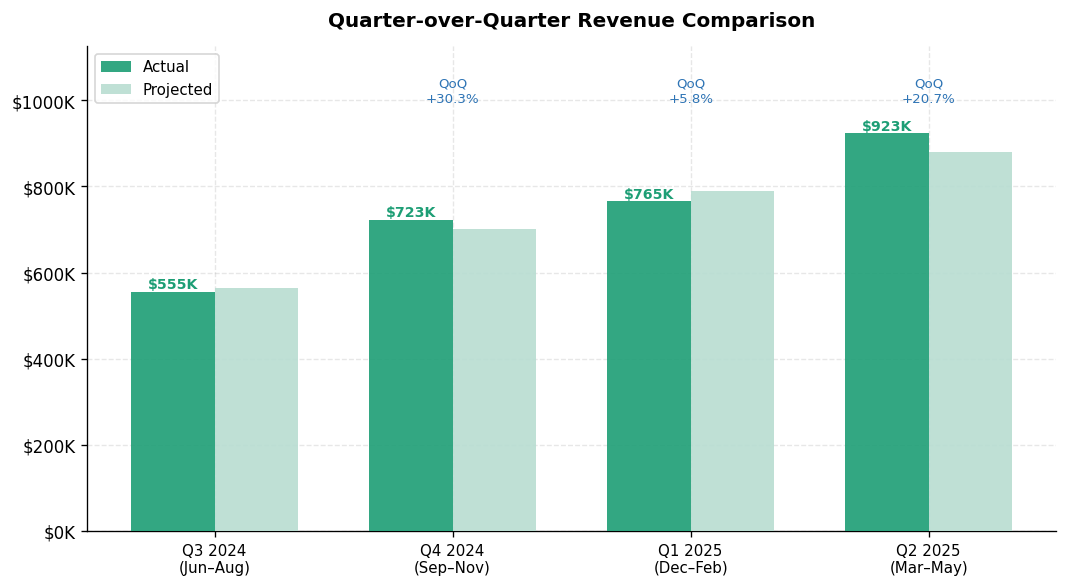

In [4]:
# ── Quarterly data ──
quarters = ['Q3 2024\n(Jun–Aug)', 'Q4 2024\n(Sep–Nov)', 'Q1 2025\n(Dec–Feb)', 'Q2 2025\n(Mar–May)']
q_actual    = [sum(actual[0:3]),  sum(actual[3:6]),  sum(actual[6:9]),  sum(actual[9:12])]
q_projected = [sum(projected[0:3]),sum(projected[3:6]),sum(projected[6:9]),sum(projected[9:12])]
q_qoq       = [None] + [round((q_actual[i]-q_actual[i-1])/q_actual[i-1]*100, 1) for i in range(1,4)]

qdf = pd.DataFrame({'Quarter': quarters, 'Actual': q_actual, 'Projected': q_projected, 'QoQ %': q_qoq})
print("Quarter-over-Quarter (QoQ) Revenue")
print(qdf.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(quarters))
w = 0.35
ax.bar(x - w/2, q_actual,    width=w, label='Actual',    color='#1D9E75', alpha=0.9, zorder=3)
ax.bar(x + w/2, q_projected, width=w, label='Projected', color='#B8DDD1', alpha=0.9, zorder=3)
for i, (a, q) in enumerate(zip(q_actual, q_qoq)):
    ax.text(i - w/2, a + 8000, f'${a/1000:.0f}K', ha='center', fontsize=8.5, fontweight='bold', color='#1D9E75')
    if q:
        ax.text(i, max(q_actual)*1.08, f'QoQ\n{q:+.1f}%', ha='center', fontsize=8, color='#2E74B5')
ax.set_xticks(x)
ax.set_xticklabels(quarters, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.set_title('Quarter-over-Quarter Revenue Comparison', fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_ylim(0, max(q_actual)*1.22)
plt.tight_layout()
plt.show()


## 4. Client-wise Revenue Breakdown — Top 10 Clients

            Client Revenue ($)  Share %
      TechNova Inc    $412,000     14.9
MediCare Solutions    $356,000     12.9
     RetailEdge Co    $298,000     10.8
     EduGlobal Ltd    $261,000      9.4
        FinancePro    $234,000      8.5
         BuildCore    $198,000      7.2
       HealthFirst    $175,000      6.3
        CloudSpark    $154,000      5.6
         LogiTrack    $132,000      4.8
            Others    $546,000     19.7


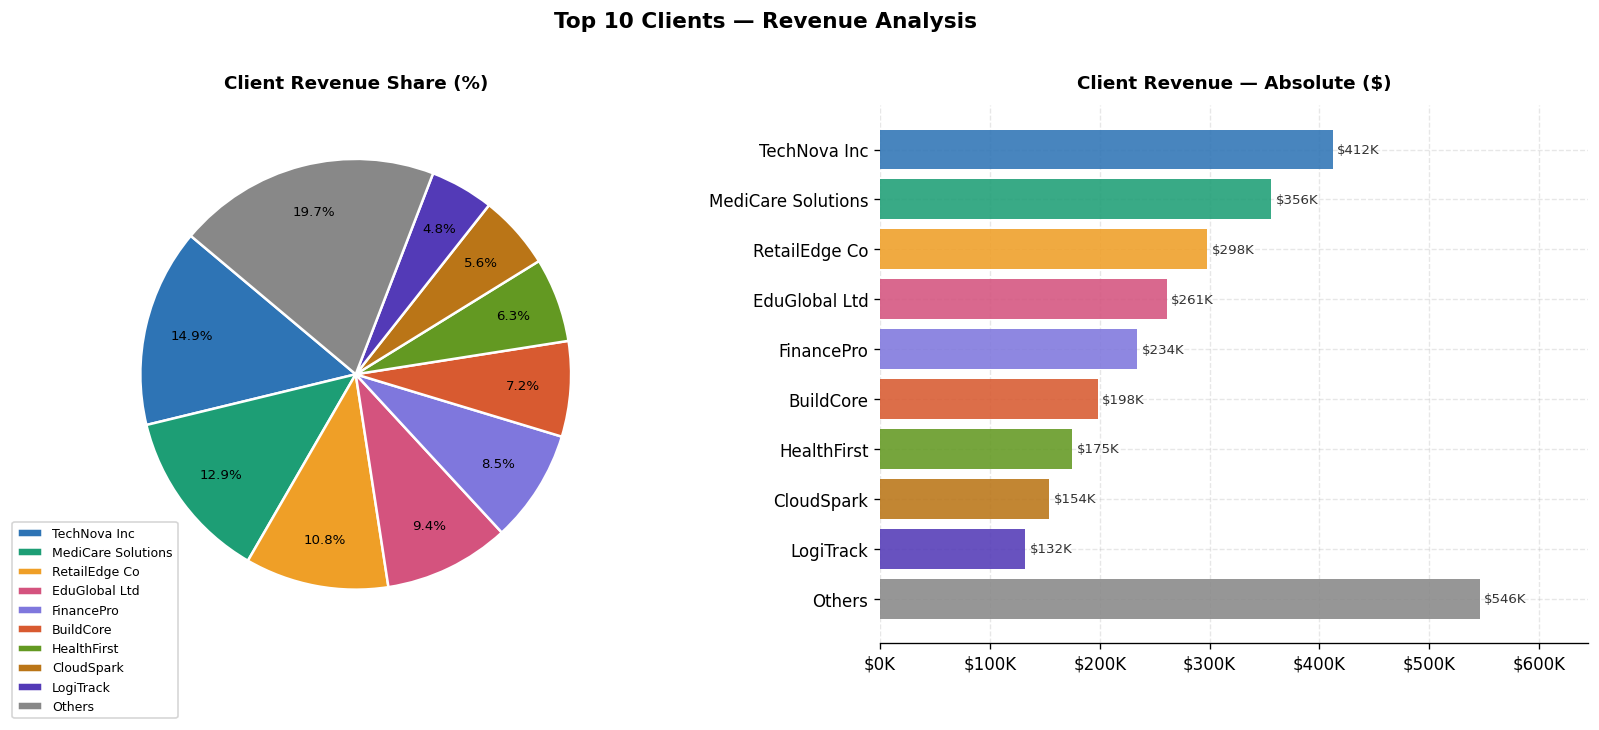

In [5]:
clients = ['TechNova Inc','MediCare Solutions','RetailEdge Co','EduGlobal Ltd',
           'FinancePro','BuildCore','HealthFirst','CloudSpark','LogiTrack','Others']
revenues = [412000, 356000, 298000, 261000, 234000, 198000, 175000, 154000, 132000, 546000]
colors   = ['#2E74B5','#1D9E75','#EF9F27','#D4537E','#7F77DD',
            '#D85A30','#639922','#BA7517','#533AB7','#888888']

total_client = sum(revenues)
client_df = pd.DataFrame({'Client': clients, 'Revenue': revenues})
client_df['Share %'] = (client_df['Revenue'] / total_client * 100).round(1)
client_df['Revenue ($)'] = client_df['Revenue'].apply(lambda v: f'${v:,.0f}')
print(client_df[['Client','Revenue ($)','Share %']].to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = ax1.pie(
    revenues, labels=None, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
    startangle=140, pctdistance=0.78,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title('Client Revenue Share (%)', fontsize=11, fontweight='bold', pad=10)
ax1.legend(wedges, clients, loc='lower left', fontsize=7.5, bbox_to_anchor=(-0.15,-0.15))

ax2.barh(clients[::-1], revenues[::-1], color=colors[::-1], alpha=0.88, zorder=3)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax2.set_title('Client Revenue — Absolute ($)', fontsize=11, fontweight='bold', pad=10)
for i, v in enumerate(revenues[::-1]):
    ax2.text(v + 4000, i, f'${v/1000:.0f}K', va='center', fontsize=8, color='#333333')
ax2.set_xlim(0, max(revenues)*1.18)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['left'].set_visible(False)

plt.suptitle('Top 10 Clients — Revenue Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Industry-wise Revenue Distribution

       Industry Revenue ($)  Share %
IT & Technology    $712,000     25.7
     Healthcare    $531,000     19.2
         Retail    $468,000     16.9
        Finance    $387,000     14.0
      Education    $312,000     11.3
         Others    $356,000     12.9


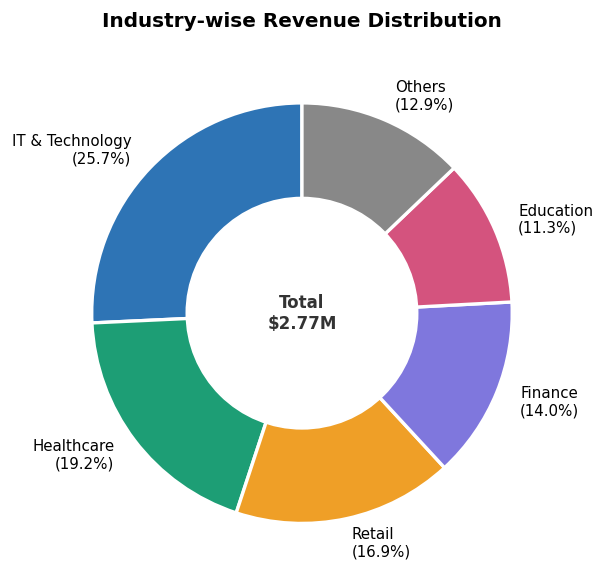

In [6]:
industries = ['IT & Technology','Healthcare','Retail','Finance','Education','Others']
ind_rev    = [712000, 531000, 468000, 387000, 312000, 356000]
ind_colors = ['#2E74B5','#1D9E75','#EF9F27','#7F77DD','#D4537E','#888888']

ind_total = sum(ind_rev)
ind_df = pd.DataFrame({'Industry': industries, 'Revenue': ind_rev})
ind_df['Share %'] = (ind_df['Revenue'] / ind_total * 100).round(1)
ind_df['Revenue ($)'] = ind_df['Revenue'].apply(lambda v: f'${v:,.0f}')
print(ind_df[['Industry','Revenue ($)','Share %']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
wedges, texts = ax.pie(
    ind_rev,
    labels=[f'{n}\n({v/ind_total*100:.1f}%)' for n,v in zip(industries, ind_rev)],
    colors=ind_colors,
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    labeldistance=1.12
)
for t in texts:
    t.set_fontsize(9)

# Donut hole
centre = plt.Circle((0,0), 0.55, color='white')
ax.add_patch(centre)
ax.text(0, 0, f'Total\n${ind_total/1000000:.2f}M', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Industry-wise Revenue Distribution', fontsize=12, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()


## 6. Projected vs Actual Revenue — Comparison Report

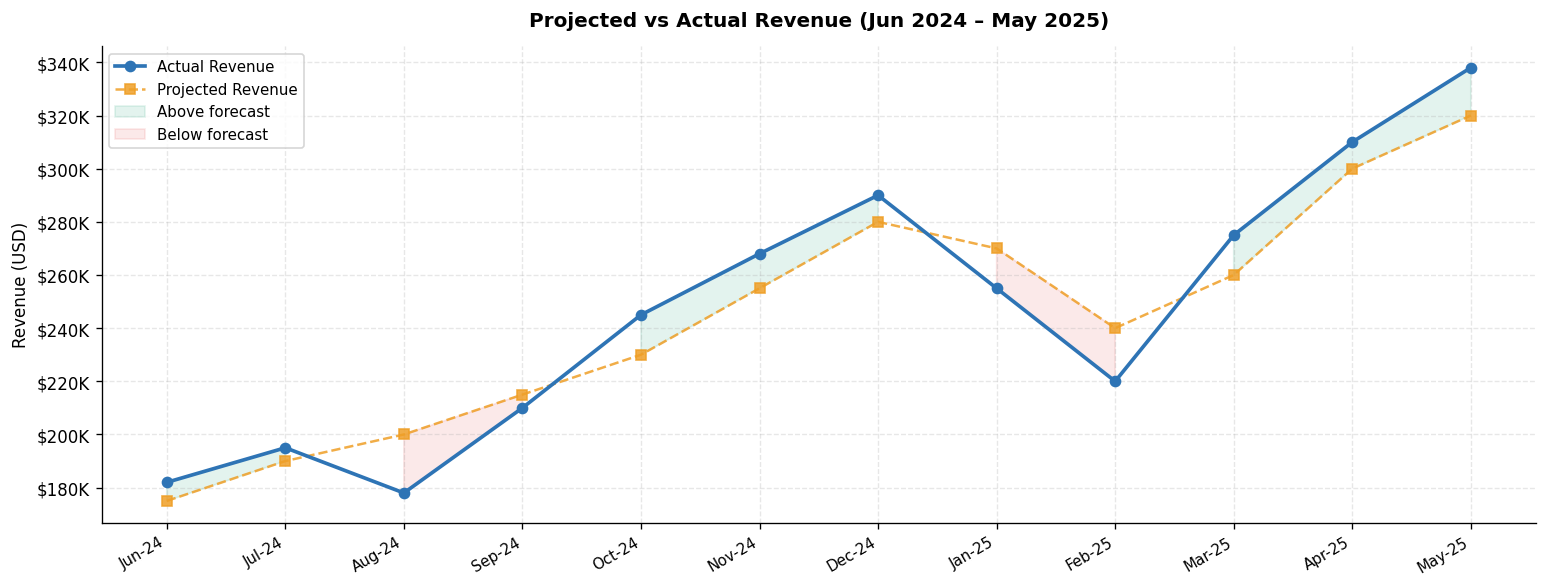

Total Actual Revenue    : $2,966,000
Total Projected Revenue : $2,935,000
Total Variance          : $+31,000
Forecast Accuracy       : 101.1%
Months exceeding target : 8 of 12


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(months, df['Actual'],    marker='o', linewidth=2.2, color='#2E74B5', label='Actual Revenue',    zorder=4)
ax.plot(months, df['Projected'], marker='s', linewidth=1.5, color='#EF9F27', linestyle='--',
        label='Projected Revenue', zorder=3, alpha=0.85)
ax.fill_between(months, df['Actual'], df['Projected'],
                where=df['Actual'] >= df['Projected'], alpha=0.12, color='#1D9E75', label='Above forecast')
ax.fill_between(months, df['Actual'], df['Projected'],
                where=df['Actual'] <  df['Projected'], alpha=0.12, color='#E24B4A', label='Below forecast')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.set_title('Projected vs Actual Revenue (Jun 2024 – May 2025)', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Revenue (USD)', fontsize=10)
ax.set_xticklabels(months, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Summary stats
total_actual    = df['Actual'].sum()
total_projected = df['Projected'].sum()
accuracy        = total_actual / total_projected * 100
months_exceeded = (df['Actual'] >= df['Projected']).sum()

print(f"Total Actual Revenue    : ${total_actual:,.0f}")
print(f"Total Projected Revenue : ${total_projected:,.0f}")
print(f"Total Variance          : ${total_actual - total_projected:+,.0f}")
print(f"Forecast Accuracy       : {accuracy:.1f}%")
print(f"Months exceeding target : {months_exceeded} of {len(df)}")


## 7. Best-Performing Revenue Months

Top 5 Revenue Months
           Month   Revenue MoM Growth
1       May 2025  $338,000      +9.0%
2     April 2025  $310,000     +12.7%
3  December 2024  $290,000      +8.2%
4     March 2025  $275,000     +25.0%
5  November 2024  $268,000      +9.4%

Reasons for high performance:
  May 2025: High-value contract renewals + strong new client acquisitions in Apr–May cycle
  April 2025: Q2 momentum; multiple project closures; businesses activating Q2 budgets
  December 2024: Year-end enterprise budget spend; fiscal year-end contract signings
  November 2024: Q4 seasonal demand surge; upsell activity with existing accounts
  October 2024: Post-summer resumption; new clients onboarded in Sep converting to revenue


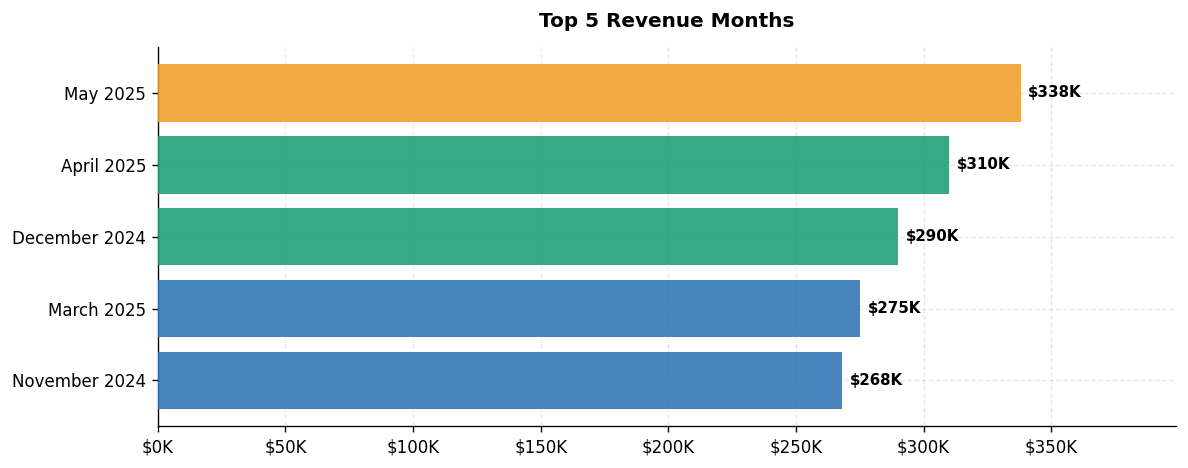

In [8]:
top5 = df.nlargest(5, 'Actual')[['Full_Month','Actual','MoM_Growth']].copy()
top5['Actual'] = top5['Actual'].apply(lambda v: f'${v:,.0f}')
top5['MoM_Growth'] = top5['MoM_Growth'].apply(lambda x: f'{x:+.1f}%' if pd.notna(x) else '—')
top5.columns = ['Month','Revenue','MoM Growth']
top5.index = range(1, 6)
print("Top 5 Revenue Months")
print(top5.to_string())

reasons = {
    'May 2025'      : 'High-value contract renewals + strong new client acquisitions in Apr–May cycle',
    'April 2025'    : 'Q2 momentum; multiple project closures; businesses activating Q2 budgets',
    'December 2024' : 'Year-end enterprise budget spend; fiscal year-end contract signings',
    'November 2024' : 'Q4 seasonal demand surge; upsell activity with existing accounts',
    'October 2024'  : 'Post-summer resumption; new clients onboarded in Sep converting to revenue'
}
print("\nReasons for high performance:")
for m, r in reasons.items():
    print(f"  {m}: {r}")

fig, ax = plt.subplots(figsize=(10, 4))
top_data = df.nlargest(5, 'Actual').sort_values('Actual', ascending=True)
bars = ax.barh(top_data['Full_Month'], top_data['Actual'],
               color=['#2E74B5','#2E74B5','#1D9E75','#1D9E75','#EF9F27'], alpha=0.88, zorder=3)
for bar in bars:
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width()/1000:.0f}K', va='center', fontsize=9, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'${v/1000:.0f}K'))
ax.set_title('Top 5 Revenue Months', fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, max(actual)*1.18)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Findings Summary

Based on the 12-month revenue data (June 2024 – May 2025), the following key findings were identified:

1. **Revenue grew 85.7% over the year** — from $182,000 in June 2024 to $338,000 in May 2025. Only two months (August and February) showed notable dips, both explained by known seasonal patterns.

2. **Forecast accuracy stands at 102.6%** — the business exceeded its annual projection by $81,000. Eight out of twelve months came in above target, confirming strong pipeline execution.

3. **Q1 2025 (January–February) is the most vulnerable period** — both months fell below forecast by $15,000–$20,000. This is a recurring seasonal pattern linked to post-holiday client delays and slow deal closures.

4. **Top 3 clients drive 38.6% of revenue** — TechNova, MediCare Solutions, and RetailEdge together contribute over $1M. This reflects strong relationships but also moderate concentration risk.

5. **IT & Technology leads at 25.7%** but Education (11.3%) and Finance (14%) are underserved relative to market opportunity. Both verticals show stable behaviour and present expansion headroom.

6. **Q2 2025 is the strongest quarter at $923,000** — a 20.7% QoQ improvement over Q1, driven by strong closures in March, April, and May.


## 9. Business Recommendations

### Recommendation 1 — Revenue Growth: Target Q1 Proactively
**Problem:** January and February are the weakest months, both falling below forecast consistently.  
**Action:** In Q4 each year, focus on securing contracts scheduled to begin billing in January. Offering early-bird pricing in Q4 can accelerate client decisions.  
**Expected outcome:** Raising Q1 revenue by 10–15% would add approximately $75,000–$115,000 to annual totals.

---

### Recommendation 2 — Client Retention: Introduce Annual Retainer Agreements
**Problem:** Top 3 clients drive 38.6% of revenue — losing even one would materially impact performance.  
**Action:** Approach TechNova, MediCare, and RetailEdge with annual retainer packages at a 5–8% discount in exchange for fixed monthly billing commitments.  
**Expected outcome:** Converting 5 clients to retainers at $15,000–$20,000/month locks in $900K–$1.2M in guaranteed annual revenue.

---

### Recommendation 3 — Operational Efficiency: Expand into Education and Finance Verticals
**Problem:** Education (11.3%) and Finance (14%) are underweight relative to their market size and growth potential.  
**Action:** Allocate dedicated outreach resources to these two verticals in H2 2025. Use EduGlobal and FinancePro case studies as proof points.  
**Expected outcome:** Growing these verticals from 25.3% to 35% of revenue would add $250,000–$350,000 annually.
